## Práctica 9: Flujo óptico.
### Autor: Juan Manuel Mena Hernandez
### Fecha: 12-05-2026


### EJERCICIO 1.  COMPARACIÓN FLUJO DE FARNEBACK ENTRE 2 IMÁGENES

Elaborar un programa en Python que tome dos imágenes y calcule el flujo de Farneback entre ellas. Una vez hecho el cálculo, el programa debe dibujar sobre la primera imagen, en sus lugares correspondientes, un subconjunto de los vectores de flujo uniformemente espaciados (por ejemplo, cada 8 o 16 píxeles), en forma de líneas de tamaño proporcional, con un pequeño cÍrculo en el origen de cada una (diagrama de agujas). El resultado se mostrará por pantalla.


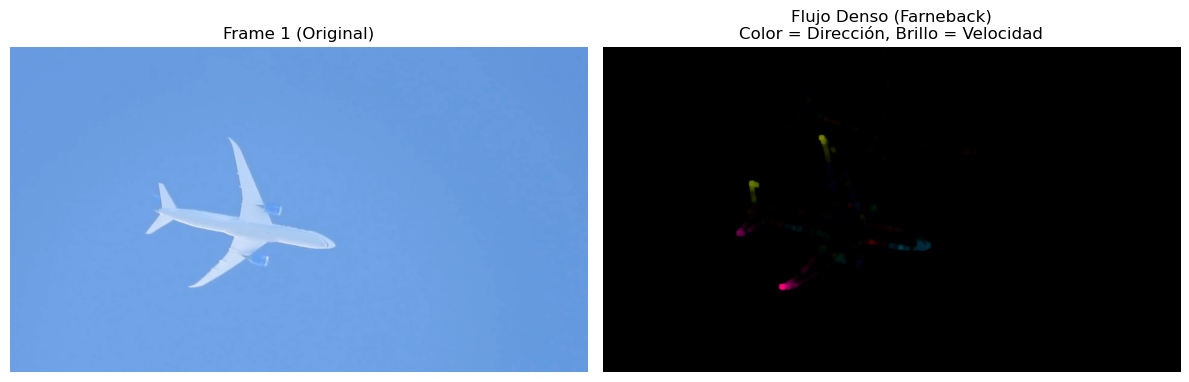

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys

img1 = cv2.imread('fotograma-1.png')
img2 = cv2.imread('fotograma-2.png')

if img1 is None or img2 is None:
    print("Error: No se encontraron las imágenes.")
    sys.exit()

# Redimensionar si es necesario (Farneback es pesado, mejor imágenes no gigantes)
if img1.shape != img2.shape:
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Convertir a escala de grises
prvs     = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
next_img = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ALGORITMO FARNEBACK
# Calcula el flujo para TODOS los píxeles
# flow tendrá dimensiones (alto, ancho, 2). El '2' son los vectores (dx, dy)
flow = cv2.calcOpticalFlowFarneback(prvs, next_img, None,
                                    pyr_scale=0.5, levels=3, winsize=15,
                                    iterations=3, poly_n=5,
                                    poly_sigma=1.2, flags=0)

# PREPARAR VISUALIZACIÓN HSV
# Creamos una imagen vacía con 3 canales (Hue, Saturation, Value)
hsv = np.zeros_like(img1)
# Ponemos la Saturación al máximo (255) para colores vivos
hsv[..., 1] = 255

# CONVERSIÓN CARTESIANA A POLAR
# Convertimos los vectores (x, y) a (Magnitud, Ángulo)
# mag: Qué tan rápido se mueve
# ang: Hacia dónde se mueve
mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
# El ÁNGULO determina el COLOR (Hue)
# Convertimos radianes a grados (OpenCV usa 0-180 para Hue)
hsv[..., 0] = ang * 180 / np.pi / 2
# La MAGNITUD determina el BRILLO (Value)
# Normalizamos para que se vea bien (0 a 255)
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

# Convertir de HSV a BGR para mostrarlo
bgr_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Frame 1 (Original)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(bgr_flow, cv2.COLOR_BGR2RGB))
plt.title("Flujo Denso (Farneback)\nColor = Dirección, Brillo = Velocidad")
plt.axis('off')
plt.tight_layout()
plt.show()

El programa calcula el flujo óptico denso de Farneback entre los dos fotogramas y lo visualiza mediante una representación HSV. Para cada píxel, el tono de color codifica la dirección del movimiento y el brillo codifica la magnitud (velocidad), ofreciendo una lectura global e intuitiva del campo de desplazamientos. Las zonas más brillantes del resultado indican mayor velocidad de movimiento, mientras que el color permite identificar el sentido del desplazamiento en cada región de la imagen.

### EJERCICIO 2. IMPLEMENTACIÓN DEL FILTRO DE KALMAN

En este ejercicio vamos a modelar el sistema como un objeto con velocidad constante. En concreto, vamos a utilizar el ratón para la implementación en tiempo real del movimiento en un lienzo negro del movimiento. El Filtro de Kalman es un estimador recursivo óptimo que minimiza el error cuadrático medio. Usalo para la implementación. 

In [1]:
import cv2
import numpy as np

# Lienzo negro
frame = np.zeros((600, 800, 3), np.uint8)

# CONFIGURACIÓN KALMAN
# 4 variables de estado (x, y, dx, dy), 2 de medición (x, y)
kalman = cv2.KalmanFilter(4, 2)
kalman.measurementMatrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], np.float32)
# Solo medimos posición
kalman.transitionMatrix = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]], np.float32)  # Física básica
kalman.processNoiseCov = np.eye(4, dtype=np.float32) * 0.03

# Función para capturar mouse
last_measurement = current_measurement = np.array([2, 1], np.float32)

def mousemove(event, x, y, flags, param):
    global current_measurement, last_measurement
    last_measurement = current_measurement.copy()
    current_measurement = np.array([np.float32(x), np.float32(y)])
    _ = event
    _ = flags
    _ = param

cv2.namedWindow("Kalman Tracker")
cv2.setMouseCallback("Kalman Tracker", mousemove)

while True:
    # PREDECIR (El cuadrado VERDE es donde la IA cree que estarás)
    prediction = kalman.predict()
    pred_x, pred_y = int(prediction[0][0]), int(prediction[1][0])
    # CORREGIR (Usamos la posición real del mouse)
    kalman.correct(current_measurement.reshape(2, 1))
    # Dibujar
    last_x, last_y = int(last_measurement[0]), int(last_measurement[1])
    curr_x, curr_y = int(current_measurement[0]), int(current_measurement[1])
    cv2.line(frame, (last_x, last_y), (curr_x, curr_y), (0, 255, 0), 1)  # Ruta real
    cv2.rectangle(frame, (pred_x - 10, pred_y - 10), (pred_x + 10, pred_y + 10), (0, 0, 255), 2)  # Predicción (Rojo)
    cv2.imshow("Kalman Tracker", frame)
    key = cv2.waitKey(30) & 0xFF
    if key == 27 or key == ord('q'):
        break  # ESC o 'q' para salir
    try:
        if cv2.getWindowProperty("Kalman Tracker", cv2.WND_PROP_VISIBLE) < 1:
            break  # Cerrar si se pulsa la X
    except cv2.error:
        break
cv2.destroyAllWindows()

El Filtro de Kalman predice en cada iteración la posición futura del ratón basándose en el modelo cinemático de velocidad constante, y corrige dicha predicción con la medición real del puntero. La línea verde traza la trayectoria real recorrida, mientras que el rectángulo rojo señala la posición estimada por el filtro antes de recibir la corrección. La separación entre ambos disminuye cuando el movimiento del ratón es suave y predecible, y se acentúa ante cambios bruscos de dirección, ilustrando así el balance entre predicción y corrección que caracteriza al algoritmo.

### EJERCICIO 3. SEGUIMIENTO MEDIANTE MEAN SHIFT

Este ejercicio propone realizar seguimiento de movimiento en tiempo real de una imagen proporcionada por webcam. El algoritmo Mean Shift es una técnica no paramétrica de escalada de gradiente hacia la moda de una distribución de probabilidad. Dada una Región de Interés (ROI) inicial, calculamos su histograma de color y realizamos una retroproyección (Back Projection) sobre los siguientes fotogramas.

In [ ]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

ret, frame = cap.read()
if not ret:
    print("No se pudo acceder a la cámara.")
    cap.release()
else:
    try:
        # Selecciona el objeto a rastrear con el ratón y pulsa ENTER o ESPACIO
        # selectROI devuelve (x, y, w, h) → c=columna(x), r=fila(y)
        c, r, w, h = cv2.selectROI("Selecciona Objeto", frame, False)
        cv2.destroyWindow("Selecciona Objeto")

        if w == 0 or h == 0:
            print("No se seleccionó ninguna región. Vuelve a ejecutar y arrastra el recuadro.")
        else:
            track_window = (c, r, w, h)

            # HISTOGRAMA DE COLOR DE LA ROI 
            # Trabajamos en HSV: el canal Hue (0) es más robusto a cambios de luz
            roi     = frame[r:r + h, c:c + w]
            hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
            # Máscara: descartar píxeles muy oscuros o sin saturación (ruido)
            mask     = cv2.inRange(hsv_roi, np.array((0., 60., 32.)), np.array((180., 255., 255.)))
            roi_hist = cv2.calcHist([hsv_roi], [0], mask, [180], [0, 180])
            cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

            term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

                # RETROPROYECCIÓN (Back Projection)
                # Para cada píxel del frame, calcula la probabilidad de que
                # pertenezca al objeto usando el histograma de la ROI.
                # Resultado: imagen en escala de grises (blanco = muy probable)
                dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)

                #MEAN SHIFT
                # Desplaza la ventana hacia la zona de mayor densidad en dst
                _, track_window = cv2.meanShift(dst, track_window, term_crit)
                x, y, tw, th = track_window

                #PANEL IZQUIERDO: seguimiento sobre el frame
                left = frame.copy()
                cv2.rectangle(left, (x, y), (x + tw, y + th), (0, 255, 0), 2)
                cv2.putText(left, "SEGUIMIENTO (Mean Shift)",
                            (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2)
                cv2.putText(left, f"pos: ({x}, {y})  tam: {tw}x{th}",
                            (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 1)

                #PANEL DERECHO: retroproyección
                # Convertir a BGR para poder añadir texto en color
                right = cv2.cvtColor(dst, cv2.COLOR_GRAY2BGR)
                # Marcar también la ventana de seguimiento en la retroproyección
                cv2.rectangle(right, (x, y), (x + tw, y + th), (0, 255, 0), 2)
                cv2.putText(right, "RETROPROYECCION (Back Projection)",
                            (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)
                cv2.putText(right, "Blanco = alta probabilidad de ser el objeto",
                            (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (200, 200, 200), 1)

                #MOSTRAR AMBOS PANELES JUNTOS
                combined = np.hstack([left, right])
                cv2.imshow("Mean Shift Tracker", combined)

                key = cv2.waitKey(30) & 0xFF
                if key == 27 or key == ord('q'):
                    break
                try:
                    if cv2.getWindowProperty("Mean Shift Tracker", cv2.WND_PROP_VISIBLE) < 1:
                        break
                except cv2.error:
                    break
    finally:
        cap.release()
        cv2.destroyAllWindows()

El algoritmo construye un histograma del canal de tono (Hue) de la región seleccionada y lo utiliza para calcular una retroproyección sobre cada nuevo fotograma, obteniendo un mapa de probabilidad en escala de grises donde los píxeles más blancos indican alta similitud de color con el objeto inicial. Mean Shift desplaza iterativamente la ventana de búsqueda hacia la zona de mayor densidad en ese mapa hasta converger en la nueva posición del objeto. La ventana de seguimiento muestra el rectángulo verde sobre el vídeo de la cámara, mientras que el panel de retroproyección permite entender qué información utiliza internamente el algoritmo para localizar el objetivo en cada fotograma.

### EJERCICIO 4. FILTRADO DE PARTÍCULAS (ALGORITMO CONDENSATION)

Este ejercicio nos propone aplicar un filtrado de partículas a un punto en movimiento. Lo haremos mediante un punto en un cuadrado negro. El Filtro de Partículas permite estimar estados en sistemas no lineales y no gaussianos.

In [ ]:
import cv2
import numpy as np

#CONFIGURACIÓN 
N = 200          # número de partículas
width, height = 800, 600
SIGMA_MOV = 15           # ruido de movimiento (px): controla dispersión de partículas
SIGMA_OBS = 50           # desviación de la gaussiana de similitud (px)

# Partículas iniciales distribuidas aleatoriamente por todo el lienzo
particles = np.random.rand(N, 2) * [width, height]

# El ratón actúa como el objeto real a rastrear
target = np.array([width / 2, height / 2], dtype=np.float64)

def mouse(event, x, y, flags, param):
    global target
    target = np.array([x, y], dtype=np.float64)

cv2.namedWindow('Particle Filter')
cv2.setMouseCallback('Particle Filter', mouse)

while True:
    frame = np.zeros((height, width, 3), dtype=np.uint8)

    # PREDICCIÓN 
    # Añadimos ruido gaussiano para modelar que el objeto puede haberse movido
    particles += np.random.randn(N, 2) * SIGMA_MOV
    # Mantener partículas dentro del lienzo
    particles[:, 0] = np.clip(particles[:, 0], 0, width  - 1)
    particles[:, 1] = np.clip(particles[:, 1], 0, height - 1)

    # EVALUACIÓN (pesos)
    # Similitud gaussiana: cuanto más cerca del objetivo, mayor peso
    dist    = np.linalg.norm(particles - target, axis=1)
    weights = np.exp(-dist**2 / (2 * SIGMA_OBS**2))
    weights /= weights.sum()   # normalizar → suman 1

    # REMUESTREO
    # Las partículas con más peso se duplican; las débiles desaparecen
    indices   = np.random.choice(N, size=N, p=weights)
    particles = particles[indices]

    # ESTIMACIÓN: centro de masa de las partículas 
    estimated = particles.mean(axis=0)
    error_px  = np.linalg.norm(estimated - target)

    # VISUALIZACIÓN
    # Partículas (azul)
    for p in particles:
        cv2.circle(frame, (int(p[0]), int(p[1])), 2, (255, 80, 0), -1)

    # Línea entre estimación y objetivo (gris tenue)
    cv2.line(frame,
             (int(estimated[0]), int(estimated[1])),
             (int(target[0]),    int(target[1])),
             (80, 80, 80), 1)

    # Objetivo real = posición del ratón (rojo)
    cv2.circle(frame, (int(target[0]),    int(target[1])),    10, (0, 0, 255),   -1)
    # Estimación = centro de masa (amarillo)
    cv2.circle(frame, (int(estimated[0]), int(estimated[1])),  8, (0, 255, 255),  2)

    # Leyenda
    cv2.putText(frame, "FILTRO DE PARTICULAS",
                (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Particulas (azul) : {N}",
                (10, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 140, 80), 1)
    cv2.putText(frame, "Objetivo   (rojo) : posicion del raton",
                (10, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (80, 80, 255), 1)
    cv2.putText(frame, "Estimacion (amarillo): centro de masa",
                (10, 102), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 220, 220), 1)
    cv2.putText(frame, f"Error estimacion: {error_px:.1f} px",
                (10, 130), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
    cv2.putText(frame, "ESC / Q para salir",
                (10, height - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (120, 120, 120), 1)

    cv2.imshow('Particle Filter', frame)

    key = cv2.waitKey(20) & 0xFF
    if key == 27 or key == ord('q'):
        break
    try:
        if cv2.getWindowProperty('Particle Filter', cv2.WND_PROP_VISIBLE) < 1:
            break
    except cv2.error:
        break

cv2.destroyAllWindows()

El filtro de partículas representa la distribución de probabilidad de la posición del objetivo mediante 200 muestras dispersas por el lienzo. En la etapa de predicción cada partícula se desplaza con ruido gaussiano para modelar la dinámica del sistema; en la evaluación se asigna a cada una un peso proporcional a su cercanía al ratón mediante una función gaussiana; y en el remuestreo se seleccionan partículas con probabilidad proporcional a dicho peso, concentrándolas progresivamente en torno al objetivo. La nube azul converge hacia el punto rojo que marca la posición real del ratón, y el círculo amarillo muestra en cada instante la estimación del filtro como centro de masa de todas las partículas, cuantificando además el error de seguimiento en píxeles.